### Data Loading

#### Loading data from libraries once and storing it in drive for fetching(one-time process)

In [ ]:
%pip install gnews
from gnews import GNews
import re
import os
import time
import pandas as pd
from datetime import date,datetime, timedelta
# --- Configuration ---
CSV_FILE = "cleaned_stock_news_2023_2025_latest(S&P200).csv"

# Date range
START_DATE = datetime(2023, 1, 1)
END_DATE = datetime(2025,12,31)

tickers = [
    "NVDA", "AAPL", "MSFT", "AMZN", "GOOGL", "GOOG", "META", "AVGO", "TSLA", "BRK-B",
    "LLY", "WMT", "JPM", "V", "XOM", "MA", "ORCL", "COST", "HD", "PG",
    "JNJ", "NFLX", "BAC", "ABBV", "KO", "CRM", "AMD", "ADBE", "QCOM", "LIN",
    "TMUS", "INTU", "TXN", "AMGN", "DIS", "PM", "CAT", "VZ", "NEE", "LOW",
    "UNP", "IBM", "HON", "AXP", "RTX", "GS", "MS", "GE", "PLTR", "SYK",
    "TMO", "SCHW", "TJX", "VRTX", "COP", "REGN", "BSX", "ADP", "MMC", "ETN",
    "CI", "C", "CB", "MDLZ", "ELV", "GILD", "DE", "LMT", "ADI", "BA",
    "AMT", "MU", "PANW", "SBUX", "ISRG", "LRCX", "NOW", "PLD", "ZTS", "MDT",
    "GEV", "KLAC", "SNPS", "CDNS", "ICE", "CRWD", "BX", "PH", "WELL",
    "MCK", "CEG", "AJG", "WM", "APH", "ITW", "SHW", "KKR", "ORLY",
    "CVS", "ECL", "AON", "CTAS", "CL", "MCO", "MSI", "PYPL", "NKE", "WMB",
    "GD", "UPS", "DASH", "CMG", "HCA", "PNC", "USB", "HWM", "EMR", "FTNT",
    "AZO", "NOC", "JCI", "BK", "ADSK", "EOG", "TRV", "ROP", "APD", "NEM",
    "MAR", "HLT", "RCL", "CSX", "APO", "CARR", "WDAY", "ABNB", "AEP", "COIN",
    "FCX", "DHR", "SPGI", "MPC", "PSX", "VLO", "KMB", "MCHP", "TEL", "F",
    "AIG", "D", "HUM", "FDX", "EW", "IQV", "STZ", "CME", "IDXX", "KHC",
    "DXCM", "A", "PAYX", "BKR", "MSCI", "O", "MET", "PRU", "GPN", "TGT",
    "DOW", "NSC", "MNST", "WBD", "KVUE", "DVN", "HAL", "SLB", "VRSK",
    "MTD", "EXC", "ED", "PEG", "SRE", "WEC", "AWK", "KDP", "LULU",
    "CHTR", "PCAR", "DLTR", "EBAY", "KR", "ROST", "FAST", "CPRT", "KMI", "URI",
    "UNH", "CSCO", "ACN", "PEP"
]

# Map values to ticker companies
TICKER_NAMES = {
    "NVDA": "NVIDIA Corporation",
    "AAPL": "Apple Inc.",
    "MSFT": "Microsoft Corporation",
    "AMZN": "Amazon.com, Inc.",
    "GOOGL": "Alphabet Inc. (Class A)",
    "GOOG": "Alphabet Inc. (Class C)",
    "META": "Meta Platforms, Inc.",
    "AVGO": "Broadcom Inc.",
    "TSLA": "Tesla, Inc.",
    "BRK-B": "Berkshire Hathaway Inc. (Class B)",
    "LLY": "Eli Lilly and Company",
    "WMT": "Walmart Inc.",
    "JPM": "JPMorgan Chase & Co.",
    "V": "Visa Inc.",
    "XOM": "Exxon Mobil Corporation",
    "MA": "Mastercard Incorporated",
    "ORCL": "Oracle Corporation",
    "COST": "Costco Wholesale Corporation",
    "HD": "The Home Depot, Inc.",
    "PG": "Procter & Gamble Company",
    "JNJ": "Johnson & Johnson",
    "NFLX": "Netflix, Inc.",
    "BAC": "Bank of America Corporation",
    "ABBV": "AbbVie Inc.",
    "KO": "The Coca-Cola Company",
    "CRM": "Salesforce, Inc.",
    "AMD": "Advanced Micro Devices, Inc.",
    "ADBE": "Adobe Inc.",
    "QCOM": "QUALCOMM Incorporated",
    "LIN": "Linde plc",
    "TMUS": "T-Mobile US, Inc.",
    "INTU": "Intuit Inc.",
    "TXN": "Texas Instruments Incorporated",
    "AMGN": "Amgen Inc.",
    "DIS": "The Walt Disney Company",
    "PM": "Philip Morris International Inc.",
    "CAT": "Caterpillar Inc.",
    "VZ": "Verizon Communications Inc.",
    "NEE": "NextEra Energy, Inc.",
    "LOW": "Lowe's Companies, Inc.",
    "UNP": "Union Pacific Corporation",
    "IBM": "International Business Machines Corporation",
    "HON": "Honeywell International Inc.",
    "AXP": "American Express Company",
    "RTX": "RTX Corporation",
    "GS": "The Goldman Sachs Group, Inc.",
    "MS": "Morgan Stanley",
    "GE": "General Electric Company",
    "PLTR": "Palantir Technologies Inc.",
    "SYK": "Stryker Corporation",
    "TMO": "Thermo Fisher Scientific Inc.",
    "SCHW": "The Charles Schwab Corporation",
    "TJX": "The TJX Companies, Inc.",
    "VRTX": "Vertex Pharmaceuticals Incorporated",
    "COP": "ConocoPhillips",
    "REGN": "Regeneron Pharmaceuticals, Inc.",
    "BSX": "Boston Scientific Corporation",
    "ADP": "Automatic Data Processing, Inc.",
    "MMC": "Marsh & McLennan Companies, Inc.",
    "ETN": "Eaton Corporation plc",
    "CI": "The Cigna Group",
    "C": "Citigroup Inc.",
    "CB": "Chubb Limited",
    "MDLZ": "Mondelez International, Inc.",
    "ELV": "Elevance Health, Inc.",
    "GILD": "Gilead Sciences, Inc.",
    "DE": "Deere & Company",
    "LMT": "Lockheed Martin Corporation",
    "ADI": "Analog Devices, Inc.",
    "BA": "The Boeing Company",
    "AMT": "American Tower Corporation",
    "MU": "Micron Technology, Inc.",
    "PANW": "Palo Alto Networks, Inc.",
    "SBUX": "Starbucks Corporation",
    "ISRG": "Intuitive Surgical, Inc.",
    "LRCX": "Lam Research Corporation",
    "NOW": "ServiceNow, Inc.",
    "PLD": "Prologis, Inc.",
    "ZTS": "Zoetis Inc.",
    "MDT": "Medtronic plc",
    "GEV": "GE Vernova Inc.",
    "KLAC": "KLA Corporation",
    "SNPS": "Synopsys, Inc.",
    "CDNS": "Cadence Design Systems, Inc.",
    "ICE": "Intercontinental Exchange, Inc.",
    "CRWD": "CrowdStrike Holdings, Inc.",
    "BX": "Blackstone Inc.",
    "PH": "Parker-Hannifin Corporation",
    "WELL": "Welltower Inc.",
    "MCK": "McKesson Corporation",
    "CEG": "Constellation Energy Corporation",
    "AJG": "Arthur J. Gallagher & Co.",
    "WM": "Waste Management, Inc.",
    "APH": "Amphenol Corporation",
    "ITW": "Illinois Tool Works Inc.",
    "SHW": "The Sherwin-Williams Company",
    "KKR": "KKR & Co. Inc.",
    "ORLY": "O'Reilly Automotive, Inc.",
    "CVS": "CVS Health Corporation",
    "ECL": "Ecolab Inc.",
    "AON": "Aon plc",
    "CTAS": "Cintas Corporation",
    "CL": "Colgate-Palmolive Company",
    "MCO": "Moody's Corporation",
    "MSI": "Motorola Solutions, Inc.",
    "PYPL": "PayPal Holdings, Inc.",
    "NKE": "NIKE, Inc.",
    "WMB": "The Williams Companies, Inc.",
    "GD": "General Dynamics Corporation",
    "UPS": "United Parcel Service, Inc.",
    "DASH": "DoorDash, Inc.",
    "CMG": "Chipotle Mexican Grill, Inc.",
    "HCA": "HCA Healthcare, Inc.",
    "PNC": "The PNC Financial Services Group, Inc.",
    "USB": "U.S. Bancorp",
    "HWM": "Howmet Aerospace Inc.",
    "EMR": "Emerson Electric Co.",
    "FTNT": "Fortinet, Inc.",
    "AZO": "AutoZone, Inc.",
    "NOC": "Northrop Grumman Corporation",
    "JCI": "Johnson Controls International plc",
    "BK": "The Bank of New York Mellon Corporation",
    "ADSK": "Autodesk, Inc.",
    "EOG": "EOG Resources, Inc.",
    "TRV": "The Travelers Companies, Inc.",
    "ROP": "Roper Technologies, Inc.",
    "APD": "Air Products and Chemicals, Inc.",
    "NEM": "Newmont Corporation",
    "MAR": "Marriott International, Inc.",
    "HLT": "Hilton Worldwide Holdings Inc.",
    "RCL": "Royal Caribbean Group",
    "CSX": "CSX Corporation",
    "APO": "Apollo Global Management, Inc.",
    "CARR": "Carrier Global Corporation",
    "WDAY": "Workday, Inc.",
    "ABNB": "Airbnb, Inc.",
    "AEP": "American Electric Power Company, Inc.",
    "COIN": "Coinbase Global, Inc.",
    "FCX": "Freeport-McMoRan Inc.",
    "DHR": "Danaher Corporation",
    "SPGI": "S&P Global Inc.",
    "MPC": "Marathon Petroleum Corporation",
    "PSX": "Phillips 66",
    "VLO": "Valero Energy Corporation",
    "KMB": "Kimberly-Clark Corporation",
    "MCHP": "Microchip Technology Incorporated",
    "TEL": "TE Connectivity Ltd.",
    "F": "Ford Motor Company",
    "AIG": "American International Group, Inc.",
    "D": "Dominion Energy, Inc.",
    "HUM": "Humana Inc.",
    "FDX": "FedEx Corporation",
    "EW": "Edwards Lifesciences Corporation",
    "IQV": "IQVIA Holdings Inc.",
    "STZ": "Constellation Brands, Inc.",
    "CME": "CME Group Inc.",
    "IDXX": "IDEXX Laboratories, Inc.",
    "KHC": "The Kraft Heinz Company",
    "DXCM": "DexCom, Inc.",
    "A": "Agilent Technologies, Inc.",
    "PAYX": "Paychex, Inc.",
    "BKR": "Baker Hughes Company",
    "MSCI": "MSCI Inc.",
    "O": "Realty Income Corporation",
    "MET": "MetLife, Inc.",
    "PRU": "Prudential Financial, Inc.",
    "GPN": "Global Payments Inc.",
    "TGT": "Target Corporation",
    "DOW": "Dow Inc.",
    "NSC": "Norfolk Southern Corporation",
    "MNST": "Monster Beverage Corporation",
    "WBD": "Warner Bros. Discovery, Inc.",
    "KVUE": "Kenvue Inc.",
    "DVN": "Devon Energy Corporation",
    "HAL": "Halliburton Company",
    "SLB": "Schlumberger Limited",
    "VRSK": "Verisk Analytics, Inc.",
    "MTD": "Mettler-Toledo International Inc.",
    "EXC": "Exelon Corporation",
    "ED": "Consolidated Edison, Inc.",
    "PEG": "Public Service Enterprise Group Incorporated",
    "SRE": "Sempra",
    "WEC": "WEC Energy Group, Inc.",
    "AWK": "American Water Works Company, Inc.",
    "KDP": "Keurig Dr Pepper Inc.",
    "LULU": "Lululemon Athletica Inc.",
    "CHTR": "Charter Communications, Inc.",
    "PCAR": "PACCAR Inc",
    "DLTR": "Dollar Tree, Inc.",
    "EBAY": "eBay Inc.",
    "KR": "The Kroger Co.",
    "ROST": "Ross Stores, Inc.",
    "FAST": "Fastenal Company",
    "CPRT": "Copart, Inc.",
    "KMI": "Kinder Morgan, Inc.",
    "URI": "United Rentals, Inc.",
    "UNH": "UnitedHealth Group Inc.",
    "CSCO": "Cisco Systems, Inc.",
    "ACN": "Accenture plc",
    "PEP": "PepsiCo, Inc."
}

# Junk keywords to filter out automated/low-quality content
JUNK_KEYWORDS = [
    "overbought", "oversold", "form 4", "insider buy", "insider sell",
    "filing", "sec filing", "nasdaq:", "nyse:", "earnings call transcript",
    "stock alert", "stock pick", "buy now", "top stocks", "click here",
    "subscribe", "sign up", "newsletter", "advertisement", "sponsored",
    "price target", "technical analysis", "moved up", "moved down",
    "unusual options", "options activity", "short interest", "stock screener",
    "benzinga", "marketbeat", "tipranks", "stock rover"
]

# Minimum word count for meaningful content
MIN_WORD_COUNT = 15

# --- Helper Functions ---

def scrub_text(text):
    """Clean the text of URLs, HTML tags, and messy whitespace."""
    if not text:
        return ""
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"&\w+;", "", text)
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def is_quality_content(text):
    """Filter out junk content and short tweets."""
    if not text:
        return False

    # Check minimum word count
    word_count = len(text.split())
    if word_count < MIN_WORD_COUNT:
        return False

    # Check for junk keywords
    text_lower = text.lower()
    if any(keyword in text_lower for keyword in JUNK_KEYWORDS):
        return False

    return True

def split_date_range(start_date, end_date, months_per_chunk=3):
    """Split date range into smaller chunks to bypass 100-article limit."""
    chunks = []
    current = start_date

    while current < end_date:
        chunk_end = min(current + timedelta(days=months_per_chunk * 30), end_date)
        chunks.append((current, chunk_end))
        current = chunk_end + timedelta(days=1)

    return chunks

def fetch_news_gnews(ticker, company_name, start_date, end_date):
    """Fetch news using GNews with chunked date ranges to get more articles."""
    all_news = []

    # Split into 3-month chunks to get more than 100 articles
    date_chunks = split_date_range(start_date, end_date, months_per_chunk=3)

    for chunk_start, chunk_end in date_chunks:
        try:
            google_news = GNews(
                language='en',
                country='US',
                start_date=(chunk_start.year, chunk_start.month, chunk_start.day),
                end_date=(chunk_end.year, chunk_end.month, chunk_end.day),
                max_results=100  # Max per chunk
            )

            # Search using both ticker and company name
            search_query = f"{ticker} OR {company_name} stock"
            news = google_news.get_news(search_query)

            if news:
                all_news.extend(news)
                print(f"    -> Found {len(news)} articles for {chunk_start.date()} to {chunk_end.date()}")

            time.sleep(0.5)  # Small delay between chunks

        except Exception as e:
            print(f"    -> Error for chunk {chunk_start.date()}: {e}")
            continue

    return all_news

# --- Main Logic ---

def main():
    final_data = []

    print("Starting Google News scraper with chunked date ranges...")
    print(f"Date range: {START_DATE.date()} to {END_DATE.date()}")
    print("Splitting into 3-month chunks to get MORE than 100 articles per ticker")
    print(f"Filters: Minimum {MIN_WORD_COUNT} words, removing junk keywords\n")
    print("Note: Make sure 'gnews' is installed: pip install gnews\n")

    for ticker in tickers:
        company_name = TICKER_NAMES.get(ticker, ticker)
        print(f"\nProcessing {ticker} ({company_name})...")

        news_items = fetch_news_gnews(ticker, company_name, START_DATE, END_DATE)
        count = 0

        for item in news_items:
            # Get published date
            pub_date = item.get("published date", "")

            # Get title and description
            title = item.get("title", "")
            description = item.get("description", "")

            # Combine title and description
            text = f"{title}. {description}" if description else title

            cleaned_text = scrub_text(text)

            # Apply quality filters
            if is_quality_content(cleaned_text):
                final_data.append({
                    "date": pub_date,
                    "tweet": cleaned_text,
                    "stock name": ticker,
                    "company name": company_name
                })
                count += 1

        print(f"  -> Total saved: {count} records")

    # Export to CSV
    if final_data:
        df = pd.DataFrame(final_data)
        df = df[["date", "tweet", "stock name", "company name"]]

        # Remove duplicates based on tweet content
        df = df.drop_duplicates(subset=["tweet"])

        # Sort by date
        df = df.sort_values("date")

        df.to_csv(CSV_FILE, index=False)
        print(f"\nSUCCESS: {len(df)} unique records saved to {CSV_FILE}")
        print(f"\nBreakdown by ticker:")
        ticker_counts = df["stock name"].value_counts().sort_index()
        for ticker, count in ticker_counts.items():
            print(f"  {ticker}: {count} articles")
        print(f"\nTotal unique articles: {len(df)}")
    else:
        print("\n No data found. Make sure 'gnews' is installed: pip install gnews")

if __name__ == "__main__":
    main()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 20.8 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=768319aa4efa384c8ca4d12b16c13cfce116ba3e77d62bf7b163e7e1f1627a10
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
Starting Google News scraper with chunked date ranges...
Date range: 2023-01-01 to 2025-12-31
Splitting into 3-month chunks to get MORE than 100 articles per ticker
Filters: Minimum 15 words, removing junk keywords

Note: Make sure 'gnews' is installed: pip install gnews


Processing NVDA (NVIDIA Corporation)...
    -> Found 24 articles for 2023-01-01 to 2023-04-01
    -> Found 56 articles for 2023-04-02 to 2023-07-01
    -> Found 45 articles for 2023-07-02 to 2023-09-30
    -> Found 55 articles for 2023

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import date,datetime, timedelta
tickers = [
    "NVDA", "AAPL", "MSFT", "AMZN", "GOOGL", "GOOG", "META", "AVGO", "TSLA", "BRK-B",
    "LLY", "WMT", "JPM", "V", "XOM", "MA", "ORCL", "COST", "HD", "PG",
    "JNJ", "NFLX", "BAC", "ABBV", "KO", "CRM", "AMD", "ADBE", "QCOM", "LIN",
    "TMUS", "INTU", "TXN", "AMGN", "DIS", "PM", "CAT", "VZ", "NEE", "LOW",
    "UNP", "IBM", "HON", "AXP", "RTX", "GS", "MS", "GE", "PLTR", "SYK",
    "TMO", "SCHW", "TJX", "VRTX", "COP", "REGN", "BSX", "ADP", "MMC", "ETN",
    "CI", "C", "CB", "MDLZ", "ELV", "GILD", "DE", "LMT", "ADI", "BA",
    "AMT", "MU", "PANW", "SBUX", "ISRG", "LRCX", "NOW", "PLD", "ZTS", "MDT",
    "GEV", "KLAC", "SNPS", "CDNS", "ICE", "CRWD", "BX", "PH", "WELL",
    "MCK", "CEG", "AJG", "WM", "APH", "ITW", "SHW", "KKR", "ORLY",
    "CVS", "ECL", "AON", "CTAS", "CL", "MCO", "MSI", "PYPL", "NKE", "WMB",
    "GD", "UPS", "DASH", "CMG", "HCA", "PNC", "USB", "HWM", "EMR", "FTNT",
    "AZO", "NOC", "JCI", "BK", "ADSK", "EOG", "TRV", "ROP", "APD", "NEM",
    "MAR", "HLT", "RCL", "CSX", "APO", "CARR", "WDAY", "ABNB", "AEP", "COIN",
    "FCX", "DHR", "SPGI", "MPC", "PSX", "VLO", "KMB", "MCHP", "TEL", "F",
    "AIG", "D", "HUM", "FDX", "EW", "IQV", "STZ", "CME", "IDXX", "KHC",
    "DXCM", "A", "PAYX", "BKR", "MSCI", "O", "MET", "PRU", "GPN", "TGT",
    "DOW", "NSC", "MNST", "WBD", "KVUE","DVN", "HAL", "SLB", "VRSK",
    "MTD", "EXC", "ED", "PEG", "SRE", "WEC", "AWK", "KDP", "LULU",
    "CHTR", "PCAR", "DLTR", "EBAY", "KR", "ROST", "FAST", "CPRT", "KMI", "URI",
    "UNH", "CSCO", "ACN", "PEP"
]
all_ticker_data = []
for ticker in tickers:
    print(f"Downloading data for {ticker}...")
    data = yf.download(ticker, start="2023-01-01", end="2025-12-31",
                       auto_adjust=False, progress=False)

    if not data.empty:
        stock_info = yf.Ticker(ticker)
        sector = stock_info.info.get('sector', 'Unknown')
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        data = data.reset_index()
        data['Stock Name'] = ticker
        data['Sector'] = sector

        print(f"  Columns: {data.columns.tolist()}")
        all_ticker_data.append(data)
    else:
        print(f"No data found for {ticker}")

df_flat = pd.concat(all_ticker_data, ignore_index=True)

df_flat = df_flat[['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Stock Name', 'Sector']]
print(f"Shape: {df_flat.shape}")
print("\nFirst few rows:")
print(df_flat.head())

## Export to CSV
df_flat.to_csv('stock_data_latest(S&P200).csv', index=False)


  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns:

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MMC']: YFTzMissingError('possibly delisted; no timezone found')


No data found for MMC
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name', 'Sector']
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock Name'

### Fetch the files directly from drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df_news = pd.read_csv('/content/drive/MyDrive/Reinforcement Learning-Based Prediction of the S&P 200 Using Financial and News Data/cleaned_stock_news_2023_2025_latest(S&P200).csv')
df_news['date'] = pd.to_datetime(df_news['date']).dt.strftime('%d/%m/%Y')
df_news.columns = df_news.columns.str.title()
df_news.head()

,Date,Tweet,Stock Name,Company Name
0,01/08/2025,5 Best Dividend Stocks To Buy For August 2025 ...,PNC,"The PNC Financial Services Group, Inc."
1,01/08/2025,"Waste Management, Inc. (WM)’s CEO Is Doing A “...",WM,"Waste Management, Inc."
2,01/08/2025,"FedEx Corporation (FDX)’s CEO Is A “Hitter,” S...",FDX,FedEx Corporation
3,01/08/2025,"Exxon, Chevron Surpass Estimates With Record O...",XOM,Exxon Mobil Corporation
4,01/08/2025,KLA Corp (KLAC) Q4 2025 Earnings Call Highligh...,KLAC,KLA Corporation


In [ ]:
df_news.columns

Index(['Date', 'Tweet', 'Stock Name', 'Company Name'], dtype='object')

In [ ]:
df_news.shape

(71726, 4)

In [ ]:
df_stock = pd.read_csv('/content/drive/MyDrive/Reinforcement Learning-Based Prediction of the S&P 200 Using Financial and News Data/stock_data_latest(S&P200).csv')
df_stock['Date'] = pd.to_datetime(df_stock['Date']).dt.strftime('%d/%m/%Y')
df_stock.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name,Sector
0,03/01/2023,14.851,14.996,14.096,14.315,14.300683,401277000,NVDA,Technology
1,04/01/2023,14.567,14.853,14.241,14.749,14.734249,431324000,NVDA,Technology
2,05/01/2023,14.491,14.564,14.148,14.265,14.250736,389168000,NVDA,Technology
3,06/01/2023,14.474,15.010,14.034,14.859,14.844140,405044000,NVDA,Technology
4,09/01/2023,15.284,16.056,15.141,15.628,15.612371,504231000,NVDA,Technology


In [ ]:
df_stock.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Stock Name', 'Sector'],
      dtype='object')

In [ ]:
df_stock.shape

(149807, 9)

### EDA

#### EDA on Financial News Data

In [ ]:
df_news.isnull().sum()

,0
Date,0
Tweet,0
Stock Name,0
Company Name,0
Embeddings,0
Month_Str,0


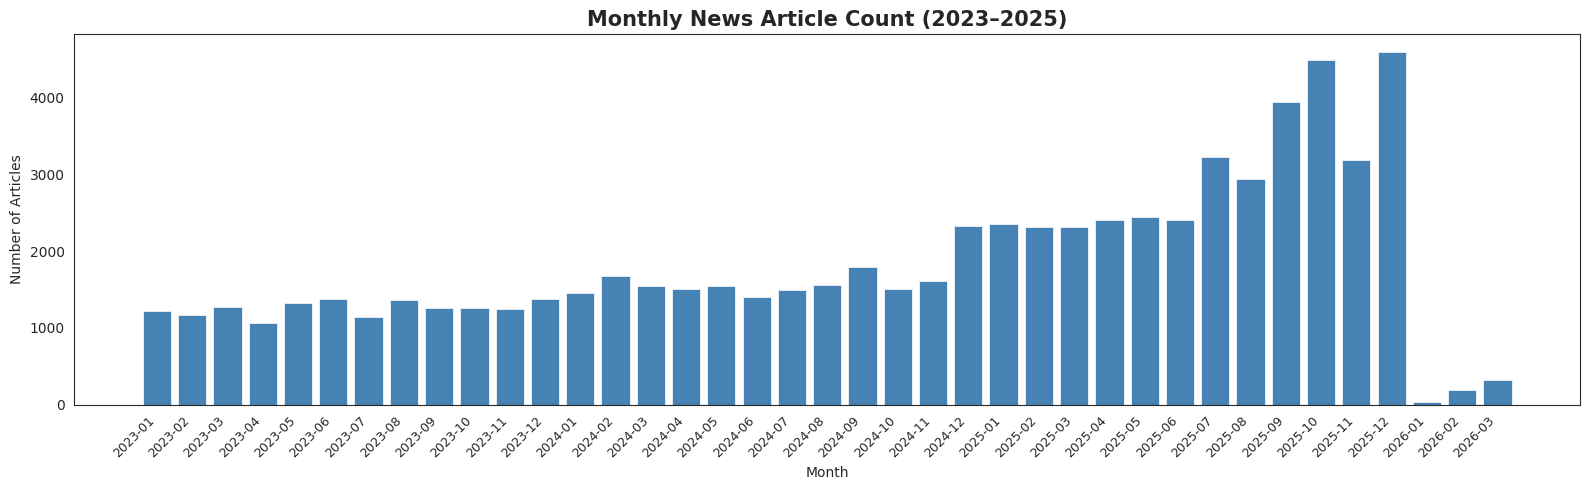

Busiest month : 2025-12 (4,600 articles)
Quietest month: 2026-01 (33 articles)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ── Monthly news article count ──────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

df_news['Date'] = pd.to_datetime(df_news['Date'], format='%d/%m/%Y')
df_news['Month_Str'] = df_news['Date'].dt.strftime('%Y-%m') # Format as YYYY-MM for correct chronological sorting

monthly = df_news.groupby('Month_Str').size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(monthly['Month_Str'], monthly['Count'], color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Monthly News Article Count (2023–2025)', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Busiest month : {monthly.loc[monthly['Count'].idxmax(), 'Month_Str']} ({monthly['Count'].max():,} articles)")
print(f"Quietest month: {monthly.loc[monthly['Count'].idxmin(), 'Month_Str']} ({monthly['Count'].min():,} articles)")

/tmp/ipykernel_20193/544572603.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, palette='viridis', ax=ax)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


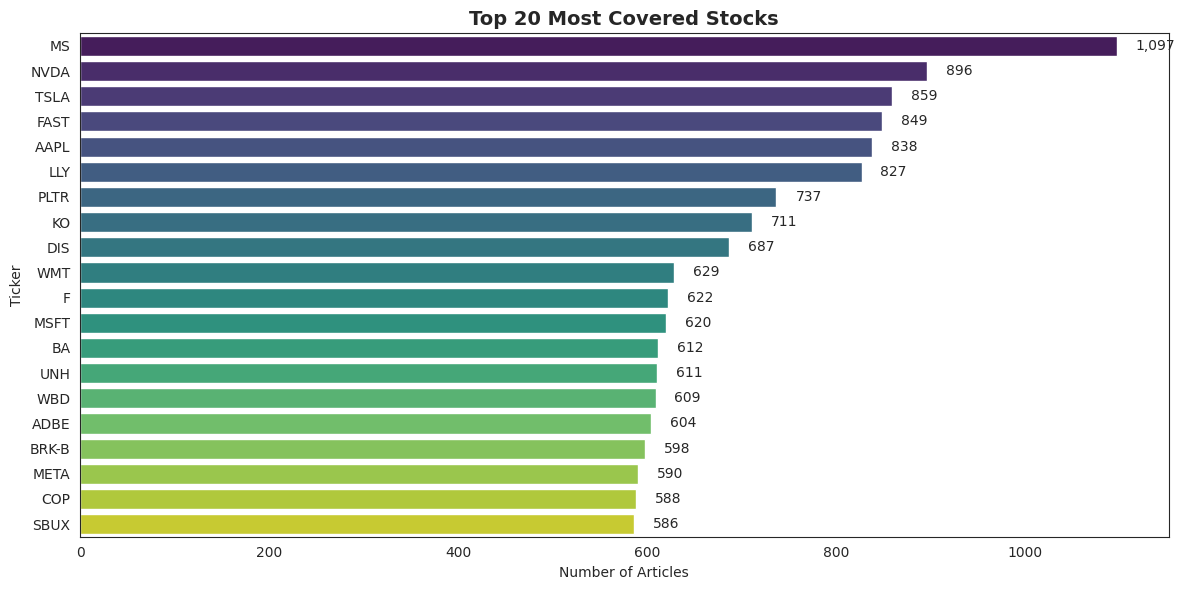

In [ ]:
# ── Top 20 most covered stocks ───────────────────────────────
top20 = df_news['Stock Name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top20.values, y=top20.index, palette='viridis', ax=ax)
ax.set_title('Top 20 Most Covered Stocks', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Articles')
ax.set_ylabel('Ticker')
for i, v in enumerate(top20.values):
    ax.text(v + 20, i, f'{v:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

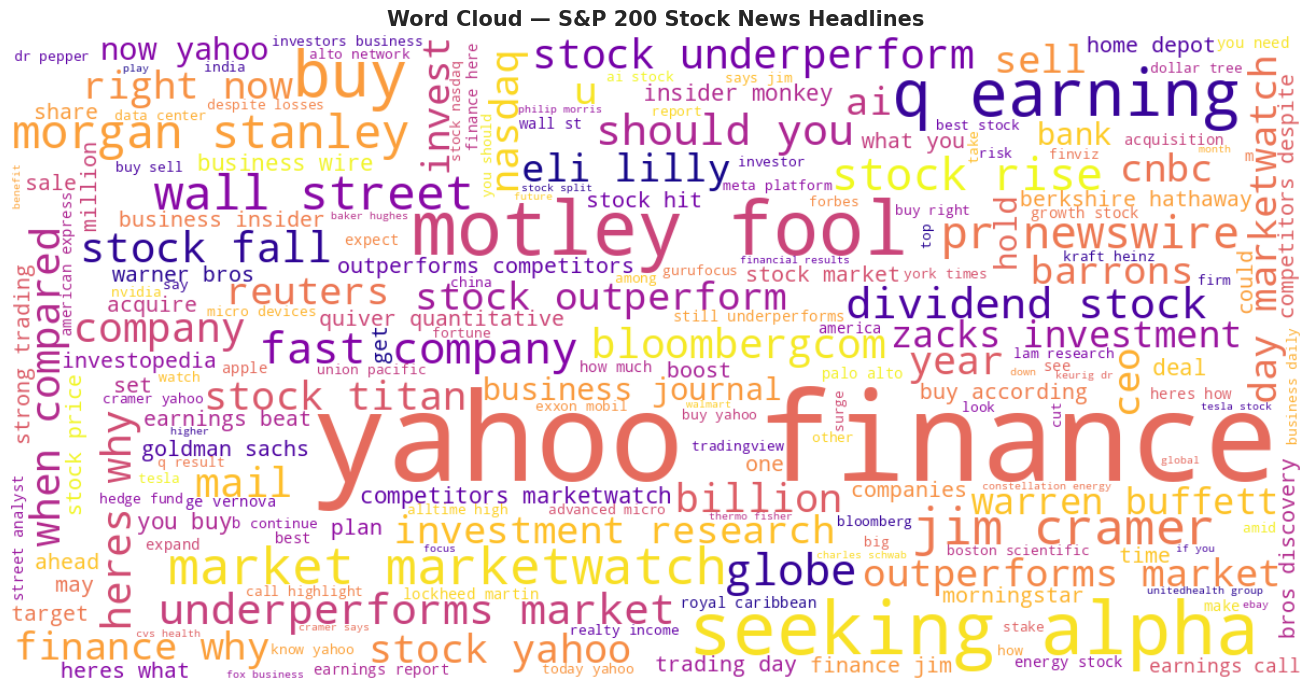

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import re

# WordCloud (install if not present)
try:
    from wordcloud import WordCloud, STOPWORDS
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("WordCloud not installed. Run: pip install wordcloud")

CUSTOM_STOP = {
    'the','a','an','is','in','of','and','to','for','on','at','by','with',
    'this','that','are','was','were','has','have','had','it','its','be',
    'as','from','or','will','not','but','can','been','more','new','up',
    'than','into','about','over','after','s','co','amp','via','inc','corp'
}

all_words = ' '.join(df_news['Tweet'].astype(str)).lower()
all_words = re.sub(r'[^a-z\s]', '', all_words)

# ── WordCloud ────────────────────────────────────────────────
if WORDCLOUD_AVAILABLE:
    wc = WordCloud(
        width=1200, height=600,
        background_color='white',
        stopwords=CUSTOM_STOP,
        max_words=200,
        colormap='plasma'
    ).generate(all_words)

    plt.figure(figsize=(16, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud — S&P 200 Stock News Headlines', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Create Embeddings from tweet column by Finbert transformer

In [ ]:
%pip install --upgrade transformers sentence-transformers tqdm -q

import torch
import numpy as np
from transformers import BertTokenizer, BertModel
from tqdm.notebook import tqdm

# ── Device setup ──────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Load model ────────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')
model     = BertModel.from_pretrained('yiyanghkust/finbert-tone')
model.to(device)
model.eval()
print("Model loaded successfully")

# ── Mean pooling helper ───────────────────────────────────────
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state          # (batch, seq, hidden)
    mask_expanded    = attention_mask.unsqueeze(-1).float()    # (batch, seq, 1)
    sum_embeddings   = torch.sum(token_embeddings * mask_expanded, dim=1)
    sum_mask         = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask                           # (batch, hidden)

# ── Embedding function ────────────────────────────────────────
def get_embeddings(texts, batch_size=64):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
        batch = texts[i : i + batch_size]

        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            output = model(**encoded)

        # Proper mean-pool (ignores padding tokens)
        embeddings = mean_pooling(output, encoded['attention_mask'])

        # L2-normalise → cosine similarity becomes dot product
        embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)

        all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

# ── Run ───────────────────────────────────────────────────────
sentences  = df_news['Tweet'].tolist()
print(f"Encoding {len(sentences):,} tweets...")

embeddings = get_embeddings(sentences, batch_size=64)

df_news['Embeddings'] = list(embeddings)

# ── Verify ────────────────────────────────────────────────────
print(f"\nDone!")
print(f"Embedding matrix shape : {embeddings.shape}")
print(f"Sample embedding (first 5 dims): {embeddings[0][:5]}")
print(f"df_news shape          : {df_news.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.8/570.8 kB 42.3 MB/s eta 0:00:00
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: yiyanghkust/finbert-tone
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully
Encoding 71,726 tweets...


Encoding:   0%|          | 0/1121 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]


Done!
Embedding matrix shape : (71726, 768)
Sample embedding (first 5 dims): [-5.0920433e-05 -4.4484939e-02 -1.5206990e-03  7.9208175e-03
  7.2789975e-02]
df_news shape          : (71726, 5)


In [ ]:
df_news.head()

,Date,Tweet,Stock Name,Company Name,Embeddings
0,01/08/2025,5 Best Dividend Stocks To Buy For August 2025 ...,PNC,"The PNC Financial Services Group, Inc.","[-5.0920433e-05, -0.04448494, -0.001520699, 0...."
1,01/08/2025,"Waste Management, Inc. (WM)’s CEO Is Doing A “...",WM,"Waste Management, Inc.","[-0.009468835, -0.045025613, -0.014149481, -0...."
2,01/08/2025,"FedEx Corporation (FDX)’s CEO Is A “Hitter,” S...",FDX,FedEx Corporation,"[-0.022724079, -0.036048323, -0.010419616, 0.0..."
3,01/08/2025,"Exxon, Chevron Surpass Estimates With Record O...",XOM,Exxon Mobil Corporation,"[-0.011347536, -0.042125393, 0.015024937, -0.0..."
4,01/08/2025,KLA Corp (KLAC) Q4 2025 Earnings Call Highligh...,KLAC,KLA Corporation,"[0.025778862, -0.071486175, 0.016954936, -0.02..."


#### EDA on Stocks data

###### Check null values in Stocks data

In [ ]:
df_stock.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Stock Name,0
Sector,0


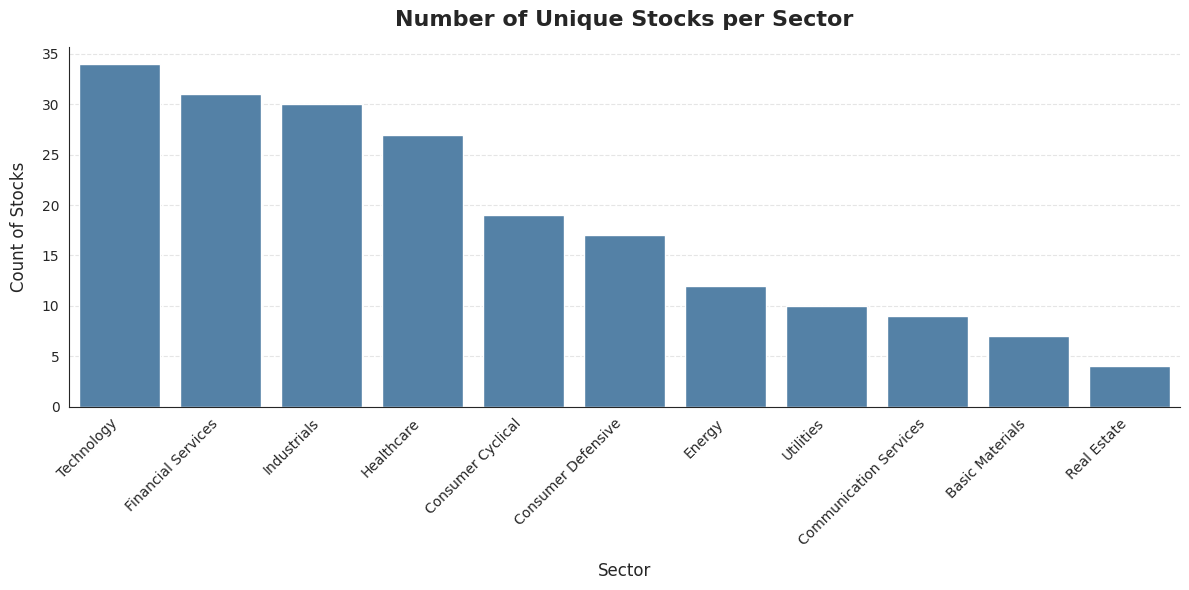

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Sector and count unique stock names
sector_counts = df_stock.groupby('Sector')['Stock Name'].nunique().sort_values(ascending=False)

# Set a clean, simple background style
sns.set_style("white")

# Plotting
plt.figure(figsize=(12, 6))

# Use a single, elegant color (e.g., 'steelblue' or 'slategray') instead of a palette
sns.barplot(x=sector_counts.index, y=sector_counts.values, color='steelblue')

# Formatting with adjusted padding and font weights
plt.title('Number of Unique Stocks per Sector', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sector', fontsize=12, labelpad=10)
plt.ylabel('Count of Stocks', fontsize=12, labelpad=10)

# Align the rotated labels to the right so they look neat and don't overlap
plt.xticks(rotation=45, ha='right')

# Remove the top and right borders (spines) for a modern, uncluttered look
sns.despine()

# Add a very subtle horizontal grid to help read the values easily
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Automatically adjust the layout so labels don't get cut off at the bottom
plt.tight_layout()

plt.show()

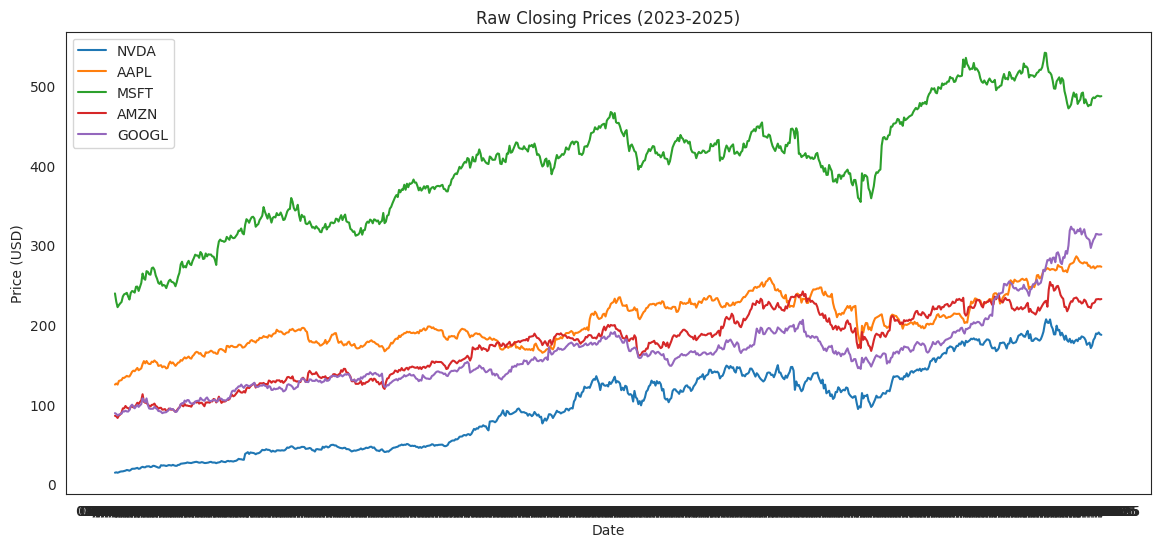

In [ ]:
# Plot closing prices for top 5 tickers
top_5_tickers = df_stock['Stock Name'].unique()[:5]

plt.figure(figsize=(14, 6))
for ticker in top_5_tickers:
    subset = df_stock[df_stock['Stock Name'] == ticker]
    plt.plot(subset['Date'], subset['Close'], label=ticker)

plt.title('Raw Closing Prices (2023-2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

/tmp/ipykernel_20193/1833813185.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_volume.values, y=sector_volume.index, palette='magma')


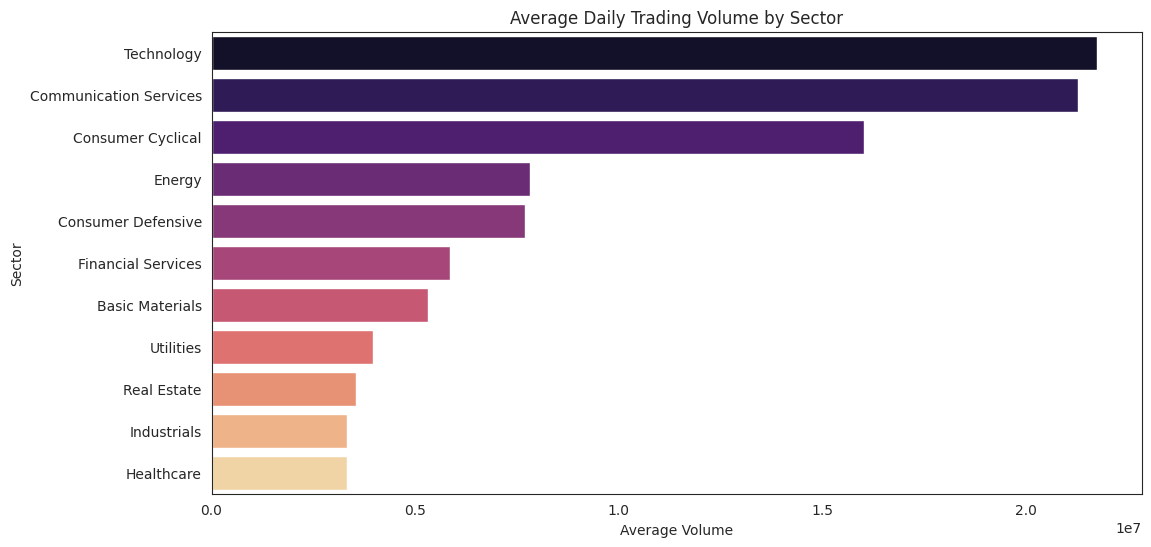

In [ ]:
# Average daily volume per sector
sector_volume = df_stock.groupby('Sector')['Volume'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=sector_volume.values, y=sector_volume.index, palette='magma')
plt.title('Average Daily Trading Volume by Sector')
plt.xlabel('Average Volume')
plt.ylabel('Sector')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

# Get ALL numerical columns
numerical_cols = df_stock.select_dtypes(include=['number']).columns.tolist()
print(f"Numerical columns to check: {numerical_cols}")

# Prepare data (drop rows with any NaN)
vif_df = df_stock[numerical_cols].dropna()

# Add constant term (required for VIF calculation)
vif_df_const = add_constant(vif_df)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = vif_df_const.columns
vif_data['VIF'] = [variance_inflation_factor(vif_df_const.values, i)
                   for i in range(vif_df_const.shape[1])]

print("\n" + "="*60)
print("VIF DIAGNOSTIC - Multicollinearity Check")
print("="*60)
print(vif_data.to_string(index=False))
print("\n" + "-"*60)
print("INTERPRETATION:")
print("  VIF = 1        : No correlation")
print("  VIF between 1-5: Moderate correlation (acceptable)")
print("  VIF between 5-10: High correlation (may need attention)")
print("  VIF > 10       : Very high correlation (red flag)")
print("="*60)

# Just highlight high VIF features without dropping
high_vif = vif_data[vif_data['VIF'] > 5]
if not high_vif.empty:
    print("\n FEATURES WITH VIF > 5 (high multicollinearity):")
    for _, row in high_vif.iterrows():
        if row['Feature'] != 'const':
            print(f"   • {row['Feature']}: VIF = {row['VIF']:.2f}")
else:
    print("\n No features with VIF > 5")

Numerical columns to check: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

VIF DIAGNOSTIC - Multicollinearity Check
  Feature          VIF
    const     2.534098
     Open 13570.800659
     High 16638.954427
      Low 15750.610770
    Close 19582.015205
Adj Close  3788.196363
   Volume     1.036492

------------------------------------------------------------
INTERPRETATION:
  VIF = 1        : No correlation
  VIF between 1-5: Moderate correlation (acceptable)
  VIF between 5-10: High correlation (may need attention)
  VIF > 10       : Very high correlation (red flag)

 FEATURES WITH VIF > 5 (high multicollinearity):
   • Open: VIF = 13570.80
   • High: VIF = 16638.95
   • Low: VIF = 15750.61
   • Close: VIF = 19582.02
   • Adj Close: VIF = 3788.20


#### From the above vif values we see that the numerical columns are highly corelated except volume column so we need to do feature engineer before dropping any variables.

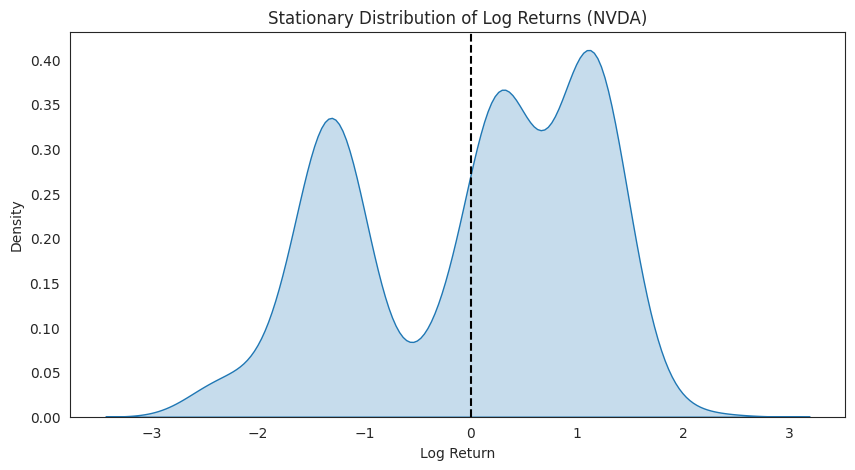

In [ ]:
import numpy as np
# Ensure data is sorted by date before shifting
df_stock = df_stock.sort_values(by=['Stock Name', 'Date'])

# Calculate daily log returns using Adj Close
df_stock['Log_Return'] = df_stock.groupby('Stock Name')['Adj Close'].transform(lambda x: np.log(x / x.shift(1)))

# Drop the first day (which becomes NaN after the shift)
df_stock = df_stock.dropna(subset=['Log_Return'])

# Plot the distribution to prove stationarity
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_stock[df_stock['Stock Name'] == top_5_tickers[0]]['Log_Return'], fill=True)
plt.title(f'Stationary Distribution of Log Returns ({top_5_tickers[0]})')
plt.xlabel('Log Return')
plt.axvline(0, color='black', linestyle='--')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

# Get ALL numerical columns
numerical_cols = df_stock.select_dtypes(include=['number']).columns.tolist()
print(f"Numerical columns to check: {numerical_cols}")

# Prepare data (drop rows with any NaN)
vif_df = df_stock[numerical_cols].dropna()

# Add constant term (required for VIF calculation)
vif_df_const = add_constant(vif_df)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = vif_df_const.columns
vif_data['VIF'] = [variance_inflation_factor(vif_df_const.values, i)
                   for i in range(vif_df_const.shape[1])]

print("\n" + "="*60)
print("VIF DIAGNOSTIC - Multicollinearity Check")
print("="*60)
print(vif_data.to_string(index=False))
print("\n" + "-"*60)
print("INTERPRETATION:")
print("  VIF = 1        : No correlation")
print("  VIF between 1-5: Moderate correlation (acceptable)")
print("  VIF between 5-10: High correlation (may need attention)")
print("  VIF > 10       : Very high correlation (red flag)")
print("="*60)

# Just highlight high VIF features without dropping
high_vif = vif_data[vif_data['VIF'] > 5]
if not high_vif.empty:
    print("\n FEATURES WITH VIF > 5 (high multicollinearity):")
    for _, row in high_vif.iterrows():
        if row['Feature'] != 'const':
            print(f"   • {row['Feature']}: VIF = {row['VIF']:.2f}")
else:
    print("\n No features with VIF > 5")

Numerical columns to check: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Log_Return']

VIF DIAGNOSTIC - Multicollinearity Check
   Feature          VIF
     const     2.534865
      Open 13572.789864
      High 16634.313701
       Low 15766.614852
     Close 19601.723309
 Adj Close  3825.855357
    Volume     1.038117
Log_Return     1.025594

------------------------------------------------------------
INTERPRETATION:
  VIF = 1        : No correlation
  VIF between 1-5: Moderate correlation (acceptable)
  VIF between 5-10: High correlation (may need attention)
  VIF > 10       : Very high correlation (red flag)

 FEATURES WITH VIF > 5 (high multicollinearity):
   • Open: VIF = 13572.79
   • High: VIF = 16634.31
   • Low: VIF = 15766.61
   • Close: VIF = 19601.72
   • Adj Close: VIF = 3825.86


#### We can see that the log return is not corelated with other variables so we can drop the columns which are highly corelated.

In [ ]:
df_stock.drop(columns=['Open','High','Low','Close','Adj Close'],inplace= True)

In [ ]:
df_stock.head()

,Date,Volume,Stock Name,Sector,Log_Return
119371,01/02/2024,862000,A,Healthcare,-0.148359
119139,01/03/2023,3132800,A,Healthcare,0.025732
119391,01/03/2024,1531000,A,Healthcare,0.018448
119411,01/04/2024,968300,A,Healthcare,0.047306
119662,01/04/2025,2302800,A,Healthcare,-0.236538


In [ ]:
merged_df = pd.merge(
    df_news,
    df_stock,
    left_on=['Date','Stock Name'],
    right_on=['Date','Stock Name'],
    how='inner'
)
# Display top 5 in the merged dataset
merged_df.head()

,Date,Tweet,Stock Name,Company Name,Embeddings,Volume,Sector,Log_Return
0,01/08/2025,5 Best Dividend Stocks To Buy For August 2025 ...,PNC,"The PNC Financial Services Group, Inc.","[-5.0920433e-05, -0.04448494, -0.001520699, 0....",2639400,Financial Services,0.090236
1,01/08/2025,"Waste Management, Inc. (WM)’s CEO Is Doing A “...",WM,"Waste Management, Inc.","[-0.009468835, -0.045025613, -0.014149481, -0....",1389500,Industrials,0.119116
2,01/08/2025,"FedEx Corporation (FDX)’s CEO Is A “Hitter,” S...",FDX,FedEx Corporation,"[-0.022724079, -0.036048323, -0.010419616, 0.0...",2213900,Industrials,-0.294463
3,01/08/2025,"Exxon, Chevron Surpass Estimates With Record O...",XOM,Exxon Mobil Corporation,"[-0.011347536, -0.042125393, 0.015024937, -0.0...",19652000,Energy,-0.030269
4,01/08/2025,KLA Corp (KLAC) Q4 2025 Earnings Call Highligh...,KLAC,KLA Corporation,"[0.025778862, -0.071486175, 0.016954936, -0.02...",1474600,Technology,0.168472


In [ ]:
merged_df.drop(columns=['Tweet'], inplace=True)

In [ ]:
merged_df.isnull().sum()

,0
Date,0
Stock Name,0
Company Name,0
Embeddings,0
Volume,0
Sector,0
Log_Return,0


In [ ]:
merged_df.shape

(64067, 7)

### Exporting merged file and displaying the progress bar

In [ ]:
import numpy as np
from tqdm.notebook import tqdm

merged_df.shape

# Define the output file path
output_csv_path = "merged_data.csv"

# Calculate the total number of rows
total_rows = len(merged_df)

# Define a chunk size (e.g., 10,000 rows per chunk) to update the progress bar
# Adjust this based on your DataFrame size and desired granularity of progress updates
chunk_size = 10000

# Initialize tqdm progress bar
with tqdm(total=total_rows, unit='rows', desc=f'Exporting to {output_csv_path}') as pbar:
    # Write the header first
    merged_df.head(0).to_csv(output_csv_path, index=False, mode='w', header=True)

    # Iterate over the DataFrame in chunks and append to the CSV
    for i in range(0, total_rows, chunk_size):
        chunk = merged_df.iloc[i:i + chunk_size]
        chunk.to_csv(output_csv_path, index=False, mode='a', header=False)
        pbar.update(len(chunk))

print(f"Successfully exported {total_rows} rows to {output_csv_path}")

Exporting to merged_data.csv:   0%|          | 0/64067 [00:00<?, ?rows/s]

Successfully exported 64067 rows to merged_data.csv


## Model Training

### Adding Libs required

In [ ]:
%pip install -q numpy pandas torch gym stable-baselines3 scikit-learn ta shimmy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 16.4 MB/s eta 0:00:00


### Define seeding

In [ ]:
# Set random seeds for reproducibility
import os
import random
import numpy as np
import torch

SEED = 42

# Python's built-in random module
random.seed(SEED)

# NumPy random seed
np.random.seed(SEED)

# PyTorch seeds
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Set PyTorch to use deterministic algorithms (slightly slower but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set environment variable for other libraries
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Random seeds set to {SEED} for reproducibility")

Random seeds set to 42 for reproducibility


### Helper functions

In [ ]:
import numpy as np

def add_features(df):
    # CRITICAL: Group by stock to prevent shifts from bleeding across tickers
    # Use transform() to keep results aligned with original dataframe
    df = df.sort_values(["Stock Name", "Date"]).reset_index(drop=True)

    # === TEMPORAL FIX: Shift Volume to previous day ===
    # In real trading, today's volume is unknown until market close
    # Use yesterday's volume as a feature (information available at decision time)
    df["Volume"] = df.groupby("Stock Name")["Volume"].transform(lambda x: x.shift(1))

    # Shifted returns (yesterday's return)
    df["Return_1"] = df.groupby("Stock Name")["Log_Return"].transform(lambda x: x.shift(1))

    # Rolling sums (simpler approach using transform + rolling)
    df["Return_5"] = df.groupby("Stock Name")["Log_Return"].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).sum()
    )
    df["Return_10"] = df.groupby("Stock Name")["Log_Return"].transform(
        lambda x: x.shift(1).rolling(10, min_periods=1).sum()
    )

    df["Trend"] = np.where(df["Return_5"] > 0, 1, -1)

    # Drop only rows with NaN in computed feature columns (preserve rows where possible)
    # Include Volume_prev in NaN check since it creates NaN on first row per stock
    df = df.dropna(subset=["Volume", "Return_1", "Return_5", "Return_10", "Trend"]).reset_index(drop=True)
    return df

def aggregate_and_shift_embeddings(df):
    """
    Aggregate embeddings per (Stock Name, Date) by taking the mean,
    then shift to previous day. Prevents leakage without dropping rows.
    """
    # Group by Stock Name and Date, aggregate embeddings (mean)
    # Each row in original df can have multiple embeddings per day
    daily_embeddings = df.groupby(['Stock Name', 'Date'])['Embeddings'].apply(
        lambda x: np.mean([emb for emb in x if emb is not None], axis=0) if any(e is not None for e in x) else None
    ).reset_index()
    daily_embeddings.columns = ['Stock Name', 'Date', 'daily_embedding']

    # Shift daily embeddings to get previous day's aggregated embedding
    # CRITICAL: Must shift WITHIN each stock group to prevent cross-ticker leakage
    daily_embeddings['prev_daily_embedding'] = daily_embeddings.groupby('Stock Name')['daily_embedding'].shift(1)

    # Merge back: each row in df gets the aggregated embedding from previous day
    df = df.merge(
        daily_embeddings[['Stock Name', 'Date', 'prev_daily_embedding']],
        on=['Stock Name', 'Date'],
        how='left'
    )

    # Replace embeddings with shifted daily aggregates
    df['Embeddings'] = df['prev_daily_embedding']
    df = df.drop(columns=['prev_daily_embedding'])

    # Remove rows where no previous-day embedding exists (first row per stock)
    df = df.dropna(subset=['Embeddings']).reset_index(drop=True)

    return df

### Defining RL code

In [ ]:
import re
import gym
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from gym import spaces
from sklearn.preprocessing import StandardScaler
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import BaseCallback

# =========================
# EMBEDDING PARSER
# =========================
def parse_embedding(x):
    if not isinstance(x, str):
        return None
    x = x.replace("[", "").replace("]", "").replace('"', "").replace("'", "").strip()
    numbers = re.findall(r"[-+]?\d*\.\d+e[-+]?\d+|[-+]?\d*\.\d+|[-+]?\d+", x)
    if len(numbers) == 0:
        return None
    return np.array([float(n) for n in numbers], dtype=np.float32)

# =========================
# LOADING DATA
# =========================
def load_data(path):
    df = pd.read_csv(path, engine="python", on_bad_lines="skip")
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).reset_index(drop=True)
    df["Embeddings"] = df["Embeddings"].apply(parse_embedding)
    df = df.dropna(subset=["Embeddings"]).reset_index(drop=True)
    emb_dim = df["Embeddings"].apply(len).mode()[0]
    df = df[df["Embeddings"].apply(lambda x: len(x) == emb_dim)].reset_index(drop=True)
    return df, emb_dim

def normalize_fit(df, cols):
    scaler = StandardScaler()
    df = df.copy()
    df[cols] = scaler.fit_transform(df[cols])
    return df, scaler

def normalize_transform(df, cols, scaler):
    df = df.copy()
    df[cols] = scaler.transform(df[cols])
    return df

# =========================
# ENVIRONMENT
# =========================
class TradingEnv(gym.Env):
    def __init__(self, df, feature_cols, emb_dim):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.emb_dim = emb_dim
        self.current_step = 0
        self.position = 0
        obs_dim = len(feature_cols) + emb_dim
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(3)

    def reset(self):
        self.current_step = 0
        self.position = 0
        return self._get_obs()

    def _get_obs(self):
        row = self.df.iloc[self.current_step]
        features = row[self.feature_cols].values.astype(np.float32)
        # Ensure 'Embeddings' is a numpy array before casting and concatenating
        embedding = np.array(row["Embeddings"]).astype(np.float32)
        return np.concatenate([features, embedding])

    def step(self, action):
        row = self.df.iloc[self.current_step]
        log_ret = row["Log_Return"]
        reward = 0
        if self.position == 1:
            reward += log_ret
        if action == 1:
            self.position = 1
        elif action == 2:
            self.position = 0
        self.current_step += 1
        done = self.current_step >= len(self.df) - 1
        return self._get_obs(), reward, done, {}

# =========================
# FEATURE EXTRACTOR
# =========================
class MultiModalExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=256):
        super().__init__(observation_space, features_dim)
        self.net = nn.Sequential(
            nn.Linear(observation_space.shape[0], 512),
            nn.ReLU(),
            nn.Linear(512, features_dim),
            nn.ReLU()
        )
    def forward(self, obs):
        return self.net(obs)

# =========================
# CUSTOM CALLBACK (EARLY STOPPING)
# =========================
class UnderfitEarlyStopCallback(BaseCallback):
    def __init__(self, eval_freq=5000, patience=10, reward_threshold=200, verbose=1):
        super().__init__(verbose)
        self.eval_freq = eval_freq
        self.patience = patience
        self.reward_threshold = reward_threshold
        self.best_mean_reward = -np.inf
        self.no_improvement_count = 0
        self.best_model_path = "best_model_early_stop.zip"

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            episodes = self.model.ep_info_buffer
            if len(episodes) > 0:
                # Convert deque to list for slicing
                episodes_list = list(episodes)
                # Get last N episodes
                n = self.eval_freq // self.model.n_envs
                recent_episodes = episodes_list[-n:] if n > 0 else episodes_list
                recent_rewards = [ep['r'] for ep in recent_episodes]
                mean_reward = np.mean(recent_rewards) if recent_rewards else -np.inf

                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    self.no_improvement_count = 0
                    self.model.save(self.best_model_path)
                    if self.verbose > 0:
                        print(f"Step {self.n_calls}: New best reward = {mean_reward:.2f}")
                else:
                    self.no_improvement_count += 1
                    if self.verbose > 0:
                        print(f"Step {self.n_calls}: No improvement. Count = {self.no_improvement_count}")

                if self.no_improvement_count >= self.patience:
                    print(f"Stopping training: No improvement for {self.patience} evaluations.")
                    return False

        return True
# =========================
# TRAIN FUNCTION WITH UNDERFITTING PREVENTION
# =========================
def train(data_path, target_reward=200, max_total_timesteps=600000, initial_timesteps=300000):
    df, emb_dim = load_data(data_path)
    # REMOVED: LabelEncoder initialization and fit_transform as Sector_Encoded is already present
    # label_encoder = LabelEncoder()
    # df['Sector_Encoded'] = label_encoder.fit_transform(df['Sector'])

    required_features = ["Sector_Encoded", "Volume", "Return_1", "Return_5", "Return_10", "Trend"]
    missing_features = [f for f in required_features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Missing features in data: {missing_features}")

    all_feature_cols = [
        "Sector_Encoded", "Volume", "Return_1", "Return_5", "Return_10", "Trend"
    ]
    numerical_feature_cols = ["Volume", "Return_1", "Return_5", "Return_10"]

    df, scaler = normalize_fit(df, numerical_feature_cols)
    env = TradingEnv(df, all_feature_cols, emb_dim)

    policy_kwargs = dict(
        features_extractor_class=MultiModalExtractor,
        features_extractor_kwargs=dict(features_dim=256),
    )

    # Initial training
    model = PPO(
        "MlpPolicy", env,
        policy_kwargs=policy_kwargs,
        verbose=1,
        learning_rate=1e-4,
        batch_size=128,
        gamma=0.99,
        n_steps=2048,
        seed=42,
    )

    callback = UnderfitEarlyStopCallback(eval_freq=5000, patience=10, reward_threshold=target_reward)
    model.learn(total_timesteps=initial_timesteps, callback=callback)

    # Load best model from early stopping
    best_model_path = "best_model_early_stop.zip"
    try:
        model = PPO.load(best_model_path)
        print(f"Loaded best model with reward {callback.best_mean_reward:.2f}")
    except:
        print("No early stop model saved, using final model.")

    # Check if underfitting occurred (best reward too low)
    if callback.best_mean_reward < target_reward:
        print(f"\n*** UNDERFITTING DETECTED: Best reward = {callback.best_mean_reward:.2f} < {target_reward} ***")
        print("Extending training with adjusted learning rate...")

        # Reduce learning rate to help fine‑tuning
        model.learning_rate = 5e-5
        # Continue training for additional timesteps
        remaining = max_total_timesteps - model.num_timesteps
        if remaining > 0:
            # New callback with higher patience
            new_callback = UnderfitEarlyStopCallback(eval_freq=5000, patience=15, reward_threshold=target_reward)
            model.learn(total_timesteps=remaining, callback=new_callback, reset_num_timesteps=False)
            # Update best reward
            if new_callback.best_mean_reward > callback.best_mean_reward:
                callback.best_mean_reward = new_callback.best_mean_reward
                model = PPO.load("best_model_early_stop.zip")

    # Final check
    if callback.best_mean_reward >= target_reward:
        print(f"\nSUCCESS: Model achieved target reward {callback.best_mean_reward:.2f} >= {target_reward}")
    else:
        print(f"\nWARNING: Model still underfitted (best reward {callback.best_mean_reward:.2f} < {target_reward}).")
        print("Consider increasing max_total_timesteps or adjusting hyperparameters.")

    model.save("ppo_trading_agent")
    return model, env, df, all_feature_cols, scaler # Removed label_encoder from return

#=========================
# INFERENCE (unchanged)
# =========================
def predict(model, env, df, label_encoder, output_csv="final_predictions.csv"):
    obs = env.reset()
    done = False
    action_map = {0: "HOLD", 1: "BUY", 2: "SELL"}
    records = []
    step = 0
    while not done:
        action, _ = model.predict(obs)
        action = int(action)
        obs, reward, done, _ = env.step(action)
        row = df.iloc[min(env.current_step, len(df) - 1)]
        trend = "UP" if row["Log_Return"] > 0 else "DOWN" if row["Log_Return"] < 0 else "NEUTRAL"

        # Convert sector encoded number back to original string name
        sector_code = row["Sector_Encoded"]
        sector_name = label_encoder.inverse_transform([sector_code])[0]

        records.append({
            "step": step,
            "date": row["Date"],
            "stock_ticker": row["Stock Name"],
            "company_name": row["Company Name"],
            "sector": sector_name,          # Now it's a string
            "log_return": row["Log_Return"],
            "price_trend": trend,
            "action": action_map[action]
        })
        step += 1
    results_df = pd.DataFrame(records)
    results_df.to_csv(output_csv, index=False)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

### Prepare data: add features and shift embeddings

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

DATA_PATH = 'merged_data.csv'

# Load raw data (WITHOUT feature engineering - will add after split)
initial_df, emb_dim = load_data(DATA_PATH)

# Sort by date for proper shifting
initial_df['Date'] = pd.to_datetime(initial_df['Date'])
initial_df = initial_df.sort_values(by=['Stock Name', 'Date']).reset_index(drop=True)

# Save pre-split, pre-feature-engineering data
output_filename_temp = "prepared_data_before_split.csv"
initial_df.to_csv(output_filename_temp, index=False)
print(f"Raw data (sorted by date, ready for split) saved to {output_filename_temp}")
display(initial_df.head())

Raw data (sorted by date, ready for split) saved to prepared_data_before_split.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Date,Stock Name,Company Name,Embeddings,Volume,Sector,Log_Return
0,2023-05-09,A,"Agilent Technologies, Inc.","[-0.015217031, -0.07355707, -0.014302995, 0.05...",1270600,Healthcare,0.018032
1,2023-06-01,A,"Agilent Technologies, Inc.","[-0.012374203, -0.05536979, 0.0019085095, 0.00...",2445000,Healthcare,-0.005514
2,2023-06-01,A,"Agilent Technologies, Inc.","[-0.01824818, -0.06858888, -0.0024578974, -0.0...",2445000,Healthcare,-0.005514
3,2023-06-07,A,"Agilent Technologies, Inc.","[-1.2739077e-05, -0.036609974, -0.0007945371, ...",1626600,Healthcare,0.009716
4,2023-08-05,A,"Agilent Technologies, Inc.","[0.002170704, -0.03880393, 0.055695828, -0.004...",1005300,Healthcare,0.273511


### Split data and label encode
###### Fit encoder ONLY on training data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import re # Import re for parse_embedding function

# =========================
# EMBEDDING PARSER (copied for self-containment)
# =========================
def parse_embedding(x):
    if not isinstance(x, str):
        return None

    x = x.replace("[", "").replace("]", "").replace('"', "").replace("'", "").strip()
    numbers = re.findall(r"[-+]?\d*\.\d+e[-+]?\d+|[-+]?\d*\.\d+|[-+]?\d+", x)

    if len(numbers) == 0:
        return None

    return np.array([float(n) for n in numbers], dtype=np.float32)

# Load prepared data (raw, unsplit)
df_prepared = pd.read_csv('prepared_data_before_split.csv')
df_prepared['Date'] = pd.to_datetime(df_prepared['Date'])

# Re-parse embeddings after loading from CSV
# This is crucial because saving to CSV converts numpy arrays to strings
df_prepared["Embeddings"] = df_prepared["Embeddings"].apply(parse_embedding)
df_prepared = df_prepared.dropna(subset=["Embeddings"]).reset_index(drop=True)

# Determine embedding dimension and filter inconsistent rows, if any
if not df_prepared.empty:
    # Assuming all embeddings should have the same dimension as initially determined
    # The emb_dim from initial_df (from load_data) would be appropriate here
    # For robustness, we re-calculate it from df_prepared itself.
    emb_dim_current = df_prepared["Embeddings"].apply(len).mode()[0]
    df_prepared = df_prepared[df_prepared["Embeddings"].apply(lambda x: len(x) == emb_dim_current)].reset_index(drop=True)
else:
    raise ValueError("No data left after parsing embeddings.")

# SPLIT into train and test FIRST
train_df = df_prepared[(df_prepared['Date'].dt.year >= 2023) & (df_prepared['Date'].dt.year <= 2024)].copy()
test_df = df_prepared[df_prepared['Date'].dt.year == 2025].copy()

# Ensure data is sorted by Stock Name and Date (critical for shift to work correctly)
train_df = train_df.sort_values(['Stock Name', 'Date']).reset_index(drop=True)
test_df = test_df.sort_values(['Stock Name', 'Date']).reset_index(drop=True)

# Aggregate embeddings per day BEFORE shifting
# This preserves all rows while preventing same-day leakage
# (aggregate_and_shift_embeddings function is defined in helper functions cell)

print("Aggregating embeddings by day (mean) and shifting...")
train_df = aggregate_and_shift_embeddings(train_df)
test_df = aggregate_and_shift_embeddings(test_df)

print(f"Training data rows: {len(train_df)} (aggregated embeddings)")
print(f"Testing data rows: {len(test_df)} (aggregated embeddings)")

# Remove rows with NaN embeddings (from first row of each stock per split)
train_df = train_df.dropna(subset=['Embeddings']).reset_index(drop=True)
test_df = test_df.dropna(subset=['Embeddings']).reset_index(drop=True)

# NOTE: Embeddings are already aggregated as numpy arrays, no need to parse again

# ADD FEATURES AFTER SPLIT (prevents distribution shift from mixing train/test in feature computation)
# IMPORTANT: add_features() now includes temporal fixes:
#   - Volume is shifted to previous day (no lookahead bias)
#   - Returns and rolling windows use only past data (shift(1))
#   - Embeddings are lagged to previous day
train_df = add_features(train_df)
test_df = add_features(test_df)

# FIT label encoder ONLY on training data sectors
label_encoder = LabelEncoder()
train_df['Sector_Encoded'] = label_encoder.fit_transform(train_df['Sector'])
train_df = train_df.drop(columns=['Sector'])

# SAFETY CHECK: Verify all test sectors were seen during training
unseen_sectors = set(test_df['Sector']) - set(label_encoder.classes_)
if unseen_sectors:
    print(f"Test data contains unseen sectors: {unseen_sectors}")
    print(f"             encoder.transform() will fail on these sectors!")
    raise ValueError(f"Test data has sectors not in training: {unseen_sectors}")
else:
    print(f"All test sectors exist in training data")

# APPLY the same fitted encoder to test data (prevents encoder leakage)
test_df['Sector_Encoded'] = label_encoder.transform(test_df['Sector'])
test_df = test_df.drop(columns=['Sector'])

# Save processed files
train_df.to_csv('train_data_2023_2024.csv', index=False)
test_df.to_csv('test_data_2025.csv', index=False)

print(f" Embeddings shifted separately per split (perfect temporal isolation)")
print(f"Same-day leakage prevented: embeddings now guaranteed from previous day")
print(f"Volume lagged to previous day (no lookahead bias)")
print(f"Features computed separately for each split (no distribution shift)")
print(f"Feature shifts properly grouped by stock (no cross-ticker bleed)")
print(f"Label encoder fitted on 2023-2024 training data only")

print("\nTraining Data Head:")
display(train_df.head())

print(f"Training data (2023-2024) saved to train_data_2023_2024.csv")

print("\nTesting Data Head:")
display(test_df.head())

print(f"Testing data (2025) saved to test_data_2025.csv")

print(f"\nSector mapping (from training data): {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Aggregating embeddings by day (mean) and shifting...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training data rows: 12040 (aggregated embeddings)
Testing data rows: 11893 (aggregated embeddings)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


All test sectors exist in training data


...

Training data (2023-2024) saved to train_data_2023_2024.csv

Testing Data Head:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Date,Stock Name,Company Name,Embeddings,Volume,Log_Return,Return_1,Return_5,Return_10,Trend,Sector_Encoded
0,2025-02-06,A,"Agilent Technologies, Inc.","[-0.030397603, -0.06266112, -0.040513963, 0.00...",2043900.0,-0.047918,0.167955,0.167955,0.167955,1,6
1,2025-02-06,A,"Agilent Technologies, Inc.","[-0.030397603, -0.06266112, -0.040513963, 0.00...",1757000.0,-0.047918,-0.047918,0.120037,0.120037,1,6
2,2025-03-04,A,"Agilent Technologies, Inc.","[-0.010049517, -0.050221257, 0.001957654, -0.0...",1757000.0,-0.263047,-0.047918,0.072120,0.072120,1,6
3,2025-03-11,A,"Agilent Technologies, Inc.","[-0.011417659, -0.08121838, 0.0037192374, 0.00...",3802400.0,0.297899,-0.263047,-0.190927,-0.190927,-1,6
4,2025-03-12,A,"Agilent Technologies, Inc.","[0.007665305, -0.06578457, -0.007754162, 0.020...",1785800.0,0.077282,0.297899,0.106971,0.106971,1,6


Testing data (2025) saved to test_data_2025.csv

Sector mapping (from training data): {'Basic Materials': np.int64(0), 'Communication Services': np.int64(1), 'Consumer Cyclical': np.int64(2), 'Consumer Defensive': np.int64(3), 'Energy': np.int64(4), 'Financial Services': np.int64(5), 'Healthcare': np.int64(6), 'Industrials': np.int64(7), 'Real Estate': np.int64(8), 'Technology': np.int64(9), 'Utilities': np.int64(10)}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Running RL agent in train and test env

In [ ]:
# =========================
# MAIN FUNCTION
# =========================
if __name__ == "__main__":
    # --- Training Phase ---
    TRAIN_DATA_PATH = "train_data_2023_2024.csv"
    # Adjust unpacking as train no longer returns label_encoder
    model, _, _, all_feature_cols, scaler = train(TRAIN_DATA_PATH) # Get model, feature_cols, AND scaler from training

    # --- Inference Phase ---
    # Load and prepare test data
    TEST_DATA_PATH = "test_data_2025.csv"
    test_df_raw, emb_dim = load_data(TEST_DATA_PATH) # Load raw test data (features already added during prep)
    # CRITICAL: Use the scaler from training (prevents data leakage)
    test_df_normalized = normalize_transform(test_df_raw.copy(), ["Volume", "Return_1", "Return_5", "Return_10"], scaler) # Normalize test data with training scaler

    # Create a new environment for prediction using the test data
    test_env = TradingEnv(test_df_normalized, all_feature_cols, emb_dim)

    print("\n=== RUNNING INFERENCE ON 2025 DATA ===\n")
    print("Note: Using scaler fitted on training data to prevent data leakage")
    # `label_encoder` is from cell `sIq09Y3qwHTI` and is in scope
    predict(model, test_env, test_df_raw, label_encoder, output_csv="predictions_2025.csv")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/gym/core.py:256: DeprecationWarning: WA

-----------------------------
| time/              |      |
|    fps             | 407  |
|    iterations      | 1    |
|    time_elapsed    | 5    |
|    total_timesteps | 2048 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| time/                   |             |
|    fps                  | 350         |
|    iterations           | 2           |
|    time_elapsed         | 11          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008996278 |
|    clip_fraction        | 0.0164      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.1        |
|    explained_variance   | -0.0173     |
|    learning_rate        | 0.0001      |
|    loss                 | 0.714       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00298    |
|    value_loss           | 2.31        |
-----------------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.18e+04     |
|    ep_rew_mean          | 1.07e+03     |
| time/                   |              |
|    fps                  | 333          |
|    iterations           | 147          |
|    time_elapsed         | 903          |
|    total_timesteps      | 301056       |
| train/                  |              |
|    approx_kl            | 0.0009861209 |
|    clip_fraction        | 0.00757      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.238       |
|    explained_variance   | 0.911        |
|    learning_rate        | 0.0001       |
|    loss                 | 0.0628       |
|    n_updates            | 1460         |
|    policy_gradient_loss | -0.00209     |
|    value_loss           | 0.276        |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. Y

Loaded best model with reward 1070.65

SUCCESS: Model achieved target reward 1070.65 >= 200

=== RUNNING INFERENCE ON 2025 DATA ===

Note: Using scaler fitted on training data to prevent data leakage


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Merging actual and predicted data for evaluation

In [ ]:
import pandas as pd

actual_data_2025 = pd.read_csv('test_data_2025.csv')
predicted_data_2025 = pd.read_csv('predictions_2025.csv')

actual_data_2025['Date'] = pd.to_datetime(actual_data_2025['Date'])
predicted_data_2025['date'] = pd.to_datetime(predicted_data_2025['date'])

# === FIX: AGGREGATE PREDICTIONS BY DATE TO ELIMINATE DUPLICATES ===
# Multiple news articles per day create duplicate prediction rows
# Solution: Take the MAJORITY action for each stock+date combination
def get_majority_action(actions):
    """Return the most common action for a given stock+date."""
    return actions.value_counts().idxmax()

# Group predictions by date, stock, and company
# Aggregate using majority voting on actions and mean on rewards
predicted_daily = predicted_data_2025.groupby(['date', 'stock_ticker', 'company_name']).agg({
    'action': get_majority_action,
    'log_return': 'first'  # Same for all rows in the group
}).reset_index()

# Rename for consistency
predicted_daily = predicted_daily.rename(columns={'date': 'Date'})

# Now merge with actual data (which is already at daily level)
merged_results = pd.merge(
    predicted_daily[['Date', 'stock_ticker', 'company_name', 'action', 'log_return']],
    actual_data_2025[['Date', 'Stock Name', 'Company Name', 'Log_Return']],
    left_on=['Date', 'stock_ticker', 'company_name'],
    right_on=['Date', 'Stock Name', 'Company Name'],
    how='inner'  # Use inner join to ensure only matching records
)

# Use actual log return (from data, not prediction)
merged_results = merged_results.drop(columns=['log_return'])
merged_results = merged_results.rename(columns={'Log_Return': 'actual_log_return'})

print("Comparison of Predicted Actions and Actual Log Returns for 2025 Test Data (Daily Aggregated):")
print(f"Number of unique stock-date combinations: {len(merged_results)}")
print("\nFirst 10 rows:")
merged_results = merged_results.drop(columns=['stock_ticker','company_name'])
display(merged_results.head(10))

Comparison of Predicted Actions and Actual Log Returns for 2025 Test Data (Daily Aggregated):
Number of unique stock-date combinations: 11697

First 10 rows:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Date,action,Stock Name,Company Name,actual_log_return
0,2025-01-05,BUY,AAPL,Apple Inc.,0.235832
1,2025-01-05,BUY,AAPL,Apple Inc.,0.235832
2,2025-01-05,BUY,AAPL,Apple Inc.,0.235832
3,2025-01-05,BUY,AMD,"Advanced Micro Devices, Inc.",-0.400590
4,2025-01-05,BUY,AMD,"Advanced Micro Devices, Inc.",-0.400590
5,2025-01-05,BUY,CVS,CVS Health Corporation,0.254929
6,2025-01-05,BUY,CVS,CVS Health Corporation,0.254929
7,2025-01-05,BUY,CVS,CVS Health Corporation,0.254929
8,2025-01-05,BUY,CVS,CVS Health Corporation,0.254929
9,2025-01-05,BUY,CVS,CVS Health Corporation,0.254929


## Evaluation

### Checking and visualizing accuracy

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

log_return_threshold = 0.005

# Evaluate correctness: does the predicted action match the actual price movement?
merged_results['is_correct'] = False

# BUY is correct if price goes up (positive log return)
merged_results.loc[
    (merged_results['action'] == 'BUY') & (merged_results['actual_log_return'] > 0),
    'is_correct'
] = True

# SELL is correct if price goes down (negative log return)
merged_results.loc[
    (merged_results['action'] == 'SELL') & (merged_results['actual_log_return'] < 0),
    'is_correct'
] = True

# HOLD is correct if price movement is small (within threshold)
merged_results.loc[
    (merged_results['action'] == 'HOLD')
    & (merged_results['actual_log_return'].abs() <= log_return_threshold),
    'is_correct'
] = True

# Calculate overall and per-action accuracy
overall_accuracy = merged_results['is_correct'].mean() * 100
print(f"Overall Prediction Accuracy (Daily Aggregated): {overall_accuracy:.2f}%")
print(f"Total daily predictions evaluated: {len(merged_results)}")

accuracy_by_action = (
    merged_results.groupby('action')['is_correct'].mean() * 100
).reset_index()
accuracy_by_action.columns = ['Action', 'Accuracy_Percentage']
accuracy_by_action['Sample_Count'] = merged_results.groupby('action').size().values

print("\nAccuracy by Action Type:")
display(accuracy_by_action)

Overall Prediction Accuracy (Daily Aggregated): 78.68%
Total daily predictions evaluated: 11697

Accuracy by Action Type:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Action,Accuracy_Percentage,Sample_Count
0,BUY,83.309826,8508
1,HOLD,2.107728,427
2,SELL,76.249095,2762


/tmp/ipykernel_20193/1871238334.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Action', y='Accuracy_Percentage', data=accuracy_by_action, palette='viridis')


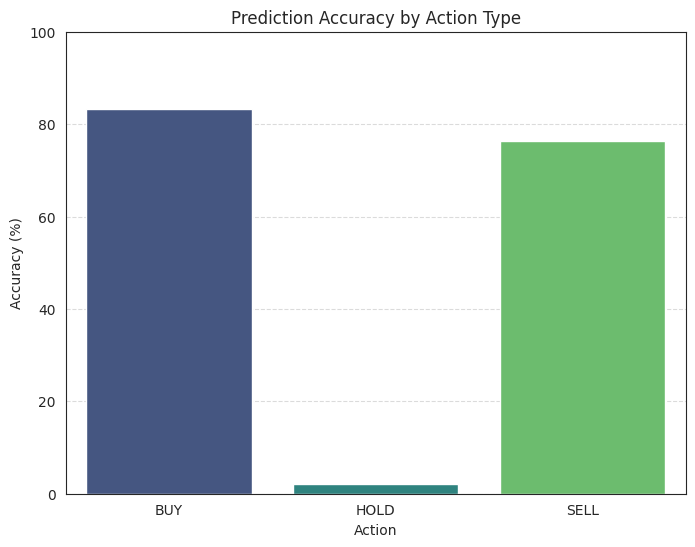

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


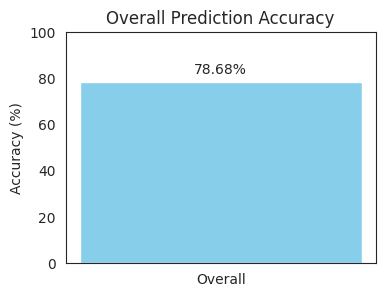

In [ ]:
# Visualize accuracy per action type
plt.figure(figsize=(8, 6))
sns.barplot(x='Action', y='Accuracy_Percentage', data=accuracy_by_action, palette='viridis')
plt.title('Prediction Accuracy by Action Type')
plt.xlabel('Action')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100) # Ensure y-axis is from 0 to 100
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize the overall accuracy as a single bar or text
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Overall'], [overall_accuracy], color='skyblue')
ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Overall Prediction Accuracy')

# Add the percentage value on top of the bar
ax.text(
    'Overall', overall_accuracy + 2,
    f'{overall_accuracy:.2f}%',
    ha='center', va='bottom'
)
plt.show()


In [ ]:
# ============================================================================
# 1. LOAD AND PREPARE DATA
# ============================================================================

# Re-load df_stock with original columns as it was modified in previous cells
df_stock = pd.read_csv('/content/drive/MyDrive/Reinforcement Learning-Based Prediction of the S&P 200 Using Financial and News Data/stock_data_latest(S&P200).csv')
df_stock['Date'] = pd.to_datetime(df_stock['Date'])

# Create price lookup table from original stock data
price_df = df_stock[['Date', 'Stock Name', 'Adj Close']].copy()
price_df.rename(columns={'Adj Close': 'price'}, inplace=True)

# Load predictions and aggregate to daily
pred_df = pd.read_csv('predictions_2025.csv')
pred_df['date'] = pd.to_datetime(pred_df['date'])

def majority_action(series):
    return series.value_counts().idxmax()

daily_pred = pred_df.groupby(['date', 'stock_ticker']).agg({
    'action': majority_action
}).reset_index()
daily_pred.rename(columns={'date': 'Date', 'stock_ticker': 'Stock Name'}, inplace=True)

# Inner join with prices
evaluation_df = daily_pred.merge(price_df, on=['Date', 'Stock Name'], how='inner')

# ============================================================================
# 2. ENHANCED EVALUATION FUNCTION WITH RISK METRICS
# ============================================================================

def evaluate_trading_with_risk_metrics(eval_df, initial_capital=10000, transaction_cost=0.001, risk_free_rate=0.02):
    """
    Enhanced evaluation function that calculates Sharpe ratio and maximum drawdown.

    Parameters:
    - eval_df: DataFrame with Date, Stock Name, action, price
    - initial_capital: Starting capital per stock
    - transaction_cost: Cost per transaction (0.001 = 0.1%)
    - risk_free_rate: Annual risk-free rate for Sharpe ratio (default 2%)
    """
    results = []

    for stock in eval_df['Stock Name'].unique():
        stock_data = eval_df[eval_df['Stock Name'] == stock].copy().sort_values('Date').reset_index(drop=True)

        if len(stock_data) == 0:
            continue

        # Track equity over time for drawdown and daily returns
        equity_curve = []
        daily_returns = []

        cash = initial_capital
        shares = 0.0
        position = 0
        first_price = stock_data['price'].iloc[0]
        bh_shares = initial_capital / first_price

        # Track for buy & hold
        bh_equity = []

        for idx, row in stock_data.iterrows():
            action = row['action']
            price = row['price']

            # Calculate current equity value
            portfolio_value = (shares * price) + cash
            equity_curve.append(portfolio_value)
            bh_equity.append(bh_shares * price)

            # Execute action
            if action == 'BUY' and position == 0:
                shares = cash / (price * (1 + transaction_cost))
                cash = 0.0
                position = 1
            elif action == 'SELL' and position == 1:
                cash = shares * price * (1 - transaction_cost)
                shares = 0.0
                position = 0

        # Handle last position (close if still holding)
        final_price = stock_data['price'].iloc[-1]
        if position == 1:
            cash = shares * final_price * (1 - transaction_cost)
            shares = 0.0

        final_value = cash
        bh_final = bh_shares * final_price

        # Calculate returns
        rl_return_pct = (final_value - initial_capital) / initial_capital * 100
        bh_return_pct = (bh_final - initial_capital) / initial_capital * 100

        # Calculate daily returns
        equity_array = np.array(equity_curve)
        daily_returns_array = np.diff(equity_array) / equity_array[:-1]

        bh_equity_array = np.array(bh_equity)
        bh_daily_returns = np.diff(bh_equity_array) / bh_equity_array[:-1]

        # Calculate Sharpe Ratio
        # Annualize returns and volatility (assuming 252 trading days)
        annual_return_rl = (final_value / initial_capital - 1)
        annual_vol_rl = np.std(daily_returns_array) * np.sqrt(252)
        sharpe_ratio_rl = (annual_return_rl - risk_free_rate) / annual_vol_rl if annual_vol_rl > 0 else 0

        annual_return_bh = (bh_final / initial_capital - 1)
        annual_vol_bh = np.std(bh_daily_returns) * np.sqrt(252)
        sharpe_ratio_bh = (annual_return_bh - risk_free_rate) / annual_vol_bh if annual_vol_bh > 0 else 0

        # Calculate Maximum Drawdown
        def calculate_max_drawdown(equity_values):
            cumulative = np.array(equity_values)
            running_max = np.maximum.accumulate(cumulative)
            drawdown = (cumulative - running_max) / running_max
            max_drawdown = np.min(drawdown)
            return max_drawdown * 100  # Convert to percentage

        max_dd_rl = calculate_max_drawdown(equity_curve)
        max_dd_bh = calculate_max_drawdown(bh_equity)

        # Number of trades
        num_trades = stock_data['action'].apply(lambda x: x in ['BUY', 'SELL']).sum()

        results.append({
            'stock': stock,
            'rl_return_pct': rl_return_pct,
            'buy_hold_return_pct': bh_return_pct,
            'excess_return_pct': rl_return_pct - bh_return_pct,
            'sharpe_ratio_rl': sharpe_ratio_rl,
            'sharpe_ratio_bh': sharpe_ratio_bh,
            'excess_sharpe': sharpe_ratio_rl - sharpe_ratio_bh,
            'max_drawdown_rl_pct': max_dd_rl,
            'max_drawdown_bh_pct': max_dd_bh,
            'num_trades': num_trades,
            'volatility_rl': annual_vol_rl * 100,
            'volatility_bh': annual_vol_bh * 100
        })

    return pd.DataFrame(results)

# ============================================================================
# 3. RUN EVALUATION
# ============================================================================

trading_results = evaluate_trading_with_risk_metrics(evaluation_df)

# ============================================================================
# 4. PRINT COMPREHENSIVE SUMMARY
# ============================================================================

print("\n" + "="*90)
print("TRADING PERFORMANCE SUMMARY (With Risk Metrics)")
print("="*90)

print("\n RETURNS:")
print(f"  RL Average Return:              {trading_results['rl_return_pct'].mean():>7.2f}%")
print(f"  Buy & Hold Average Return:      {trading_results['buy_hold_return_pct'].mean():>7.2f}%")
print(f"  Average Excess Return:          {trading_results['excess_return_pct'].mean():>7.2f}%")

print("\n RISK-ADJUSTED RETURNS (Sharpe Ratio):")
print(f"  RL Average Sharpe Ratio:        {trading_results['sharpe_ratio_rl'].mean():>7.2f}")
print(f"  Buy & Hold Avg Sharpe Ratio:    {trading_results['sharpe_ratio_bh'].mean():>7.2f}")
print(f"  Average Excess Sharpe:          {trading_results['excess_sharpe'].mean():>7.2f}")

print("\n DRAWDOWN ANALYSIS:")
print(f"  RL Avg Max Drawdown:            {trading_results['max_drawdown_rl_pct'].mean():>7.2f}%")
print(f"  Buy & Hold Avg Max Drawdown:    {trading_results['max_drawdown_bh_pct'].mean():>7.2f}%")
print(f"  Stocks with lower RL drawdown:  {(trading_results['max_drawdown_rl_pct'] > trading_results['max_drawdown_bh_pct']).sum():>7d}")

print("\n VOLATILITY (Annualized):")
print(f"  RL Average Volatility:          {trading_results['volatility_rl'].mean():>7.2f}%")
print(f"  Buy & Hold Average Volatility:  {trading_results['volatility_bh'].mean():>7.2f}%")

print("\n WIN RATE:")
print(f"  Stocks where RL outperformed:   {(trading_results['excess_return_pct'] > 0).sum():>7d}")
print(f"  Stocks where RL had better Sharpe: {(trading_results['excess_sharpe'] > 0).sum():>7d}")

print("\n TRADING ACTIVITY:")
print(f"  Average Number of Trades:       {trading_results['num_trades'].mean():>7.1f}")
print(f"  Total Stocks Evaluated:         {len(trading_results):>7d}")

print("="*90)

# Display top performers by different metrics
print("\n\n TOP 5 STOCKS BY EXCESS RETURN:")
top_return = trading_results.nlargest(5, 'excess_return_pct')[['stock', 'rl_return_pct', 'buy_hold_return_pct', 'excess_return_pct']]
print(top_return.to_string(index=False))

print("\n\n TOP 5 STOCKS BY SHARPE RATIO (RL):")
top_sharpe = trading_results.nlargest(5, 'sharpe_ratio_rl')[['stock', 'sharpe_ratio_rl', 'sharpe_ratio_bh', 'excess_sharpe', 'max_drawdown_rl_pct']]
print(top_sharpe.to_string(index=False))

print("\n\n TOP 5 STOCKS BY LOWEST DRAWDOWN (RL):")
lowest_dd = trading_results.nsmallest(5, 'max_drawdown_rl_pct')[['stock', 'max_drawdown_rl_pct', 'max_drawdown_bh_pct', 'rl_return_pct']]
print(lowest_dd.to_string(index=False))



TRADING PERFORMANCE SUMMARY (With Risk Metrics)

 RETURNS:
  RL Average Return:                14.87%
  Buy & Hold Average Return:        15.29%
  Average Excess Return:            -0.41%

 RISK-ADJUSTED RETURNS (Sharpe Ratio):
  RL Average Sharpe Ratio:           0.10
  Buy & Hold Avg Sharpe Ratio:       0.14
  Average Excess Sharpe:            -0.04

 DRAWDOWN ANALYSIS:
  RL Avg Max Drawdown:             -15.01%
  Buy & Hold Avg Max Drawdown:     -20.91%
  Stocks with lower RL drawdown:      108

 VOLATILITY (Annualized):
  RL Average Volatility:            69.56%
  Buy & Hold Average Volatility:    90.97%

 WIN RATE:
  Stocks where RL outperformed:        60
  Stocks where RL had better Sharpe:      53

 TRADING ACTIVITY:
  Average Number of Trades:          25.3
  Total Stocks Evaluated:             196


 TOP 5 STOCKS BY EXCESS RETURN:
stock  rl_return_pct  buy_hold_return_pct  excess_return_pct
 LULU      -1.176447           -50.716517          49.540070
 CHTR       3.740338    

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ! Optional to remove widgets such that we can upload code on github/gitlab
import json

# Type the exact name of the file you uploaded to the sidebar
filename = "Data_Mining_Final.ipynb"

# Load the notebook
with open(filename, 'r', encoding='utf-8') as f:
    nb = json.load(f)

# Remove the problematic widgets metadata
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']
    print("Success: Widget metadata removed!")
else:
    print("No widget metadata found in this file.")

# Save the cleaned notebook
fixed_filename = "FIXED_" + filename
with open(fixed_filename, 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=2)

print(f"Saved! You can now download {fixed_filename} from the sidebar and upload it to GitHub.")